# Part 1 - EDA do detector de carpet


**def:**
A detecção de um "carpete" em sinais de vibração (frequentemente chamado de carpete de vibrações ou noise floor elevado) refere-se ao levantamento generalizado da linha de base do ruído de fundo em uma região do espectro de frequência (FFT). Em vez de picos finos e isolados, o sinal mostra uma "massa" contínua e densa de energia vibracional, assemelhando-se ao formato plano e peludo de um tapete.
O surgimento desse fenômeno na análise preditiva indica, de forma quase unânime, deficiência de lubrificação em rolamentos ou atrito excessivo entre componentes metal-metal.


In [1]:
# libs import and path build

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

ROOT = Path.cwd().resolve()
PART1_CANDIDATES = [
    ROOT / 'source' / 'part1',
    ROOT / 'data' / 'part1',
    ROOT.parent / 'source' / 'part1',
    ROOT.parent / 'data' / 'part1',
]

PART1_DIR = next(
    (path for path in PART1_CANDIDATES if (path / 'labels.csv').exists() and (path / 'data').exists()),
    None,
)

if PART1_DIR is None:
    searched = '\n'.join(str(path) for path in PART1_CANDIDATES)
    raise FileNotFoundError(f'Nao encontrei a part1. Caminhos testados:\n{searched}')

DATA_DIR = PART1_DIR / 'data'
print(f'Usando dados da Part 1 em: {PART1_DIR}')

Usando dados da Part 1 em: C:\Users\vinicius\Documents\MEUGITHUB\Vibration_challenge\source\part1


## Relação entre labels e sinais

Cada linha de `labels.csv` representa um arquivo de vibração. Para cada linha do `labels.csv` o nome do sample_id serve como identificador do arquivo de sinal (`sample_id.csv`) e cada linha contem um lista de json com as regiões onde houve 'carpet'



In [3]:
# load do arquivo de labels

labels = pd.read_csv(PART1_DIR / 'labels.csv')
labels['sample_id'] = labels['sample_id'].astype(str)
labels['regions_obj'] = labels['regions'].apply(json.loads)
labels['tem_carpet'] = labels['regions_obj'].apply(lambda regions: len(regions) > 0)
labels['n_regioes'] = labels['regions_obj'].apply(len)
labels['largura_total_hz'] = labels['regions_obj'].apply(
    lambda regions: sum(end - start for start, end in regions)
)

display(labels.head())

,sample_id,regions,regions_obj,tem_carpet,n_regioes,largura_total_hz
0,ef823432-8249-5cba-ace1-3c5192b825b7,"[[4000.0, 5300.0]]","[[4000.0, 5300.0]]",True,1,1300.0
1,9b7308b8-1db3-5130-b498-b81dffaedd7d,"[[4100.0, 5750.0]]","[[4100.0, 5750.0]]",True,1,1650.0
2,e5b6beb7-fbd1-5bfb-ae40-fb61922f2215,"[[3375.0, 3643.0], [4000.0, 5250.0]]","[[3375.0, 3643.0], [4000.0, 5250.0]]",True,2,1518.0
3,0209af20-34f8-5c0e-bdad-94b1e7046f71,"[[3525.0, 4438.0]]","[[3525.0, 4438.0]]",True,1,913.0
4,505894c3-1d24-560f-9588-d758b1fb7004,"[[3760.0, 4000.0], [4800.0, 5640.0]]","[[3760.0, 4000.0], [4800.0, 5640.0]]",True,2,1080.0


In [4]:
# algumas estatísticas básicas do dataset
display(
    labels.agg(
        total_amostras=('sample_id', 'count'),
        amostras_com_carpet=('tem_carpet', 'sum'),
        media_regioes=('n_regioes', 'mean'),
        largura_media_hz=('largura_total_hz', 'mean'),
    )
)

,sample_id,tem_carpet,n_regioes,largura_total_hz
total_amostras,126.0,NaN,NaN,NaN
amostras_com_carpet,NaN,100.0,NaN,NaN
media_regioes,NaN,NaN,1.190476,NaN
largura_media_hz,NaN,NaN,NaN,1257.595238


In [5]:
# funções auxiliares para carregar os dados de cada amostra
def sampling_rate(t):
    dt = np.diff(np.asarray(t, dtype=np.float64))
    dt = dt[dt > 0]
    if len(dt) == 0:
        return np.nan
    return 1.0 / np.median(dt)


def load_wave(sample_id):
    df = pd.read_csv(DATA_DIR / f'{sample_id}.csv')
    t_col = 't' if 't' in df.columns else df.columns[0]
    data_col = 'data' if 'data' in df.columns else df.columns[-1]

    t = df[t_col].to_numpy(dtype=np.float64)
    x = df[data_col].to_numpy(dtype=np.float64)
    fs = sampling_rate(t)
    return t, x, df, fs

In [6]:
records = []
for sample_id in labels['sample_id']:
    t, x, _, fs = load_wave(sample_id)
    records.append(
        {
            'sample_id': sample_id,
            'n_pontos': len(t),
            'duracao_s': float(t[-1] - t[0]) if len(t) else np.nan,
            'fs_hz': fs,
            'nyquist_hz': fs / 2,
            'media_g': float(np.mean(x)),
            'std_g': float(np.std(x)),
            'max_abs_g': float(np.max(np.abs(x))),
        }
    )

signals_info = pd.DataFrame(records).merge(
    labels[['sample_id', 'tem_carpet', 'n_regioes', 'largura_total_hz']],
    on='sample_id',
    how='left',
)

display(signals_info.head())



,sample_id,n_pontos,duracao_s,fs_hz,nyquist_hz,media_g,std_g,max_abs_g,tem_carpet,n_regioes,largura_total_hz
0,ef823432-8249-5cba-ace1-3c5192b825b7,32768,2.080444,15750.0,7875.0,-4.882812e-10,0.418864,2.381361,True,1,1300.0
1,9b7308b8-1db3-5130-b498-b81dffaedd7d,32768,2.077411,15773.0,7886.5,-6.103516e-10,1.273097,5.552917,True,1,1650.0
2,e5b6beb7-fbd1-5bfb-ae40-fb61922f2215,32768,2.075437,15788.0,7894.0,-3.051758e-11,1.198830,5.113972,True,2,1518.0
3,0209af20-34f8-5c0e-bdad-94b1e7046f71,32768,2.020036,16221.0,8110.5,2.441406e-09,1.952725,7.556802,True,1,913.0
4,505894c3-1d24-560f-9588-d758b1fb7004,32768,2.020036,16221.0,8110.5,2.441406e-10,1.023103,4.740221,True,2,1080.0


**INFORMAÇÕES das features disponíveis**
* sample_id: Identificador do sinal
* n_pontos: Número de amostras do sinal
* duracao_s: Duração da aquisição
* fs_hz: frequência de amostragem (1/mediana(dt))
* nyquist_hz: Frequência de Nyquist (metada da frquência de amostragem)
* media_g: Média da aceleração
* std_g: Desvio padrão
* max_abs_g: Pico máximo absoluto



In [8]:
# informações estatísticas sobre os sinais
display(signals_info.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,126,126,ef823432-8249-5cba-ace1-3c5192b825b7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_pontos,126.0,NaN,NaN,NaN,30850.031746,6608.390647,4096.0,32768.0,32768.0,32768.0,32768.0
duracao_s,126.0,NaN,NaN,NaN,1.950762,0.3486,0.255347,2.024029,2.030677,2.069996,2.083487
fs_hz,126.0,NaN,NaN,NaN,15774.325397,2246.327192,7845.0,15816.25,16110.0,16181.0,31674.0
nyquist_hz,126.0,NaN,NaN,NaN,7887.162698,1123.163596,3922.5,7908.125,8055.0,8090.5,15837.0
media_g,126.0,NaN,NaN,NaN,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0
std_g,126.0,NaN,NaN,NaN,1.706496,1.470623,0.048595,0.727481,1.196154,2.312,7.837199
max_abs_g,126.0,NaN,NaN,NaN,6.873369,5.100372,0.121316,2.833593,5.270325,9.723869,21.861757
tem_carpet,126,2,True,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_regioes,126.0,NaN,NaN,NaN,1.190476,0.855236,0.0,1.0,1.0,2.0,4.0


In [10]:
# estatísticas agrupadas por presença de carpet
display(
    signals_info.groupby('tem_carpet')[['duracao_s', 'fs_hz', 'std_g', 'max_abs_g']]
    .median()
    .rename(index={False: 'sem_carpet', True: 'com_carpet'})
)

,duracao_s,fs_hz,std_g,max_abs_g
tem_carpet,,,,
sem_carpet,2.025092,16180.5,0.728727,2.703036
com_carpet,2.031180,16102.0,1.374251,5.974406


## Leitura do sinal de vibração

O sinal bruto está no domínio do tempo e pode ser invertido para o domínio da frequência que vai enfatizar as regiões de energia concentrada. Essa concentração de energia nos permite tentar identificar essas anomalias. A faixa inferior a `1000 Hz` é usada como uma fronteira pratica, e não deve ser considerada

https://www.youtube.com/shorts/qyoHvJfzF58

In [12]:
def compute_psd(t, x, nperseg_max=8192):
    x = np.asarray(x, dtype=np.float64)
    x = signal.detrend(x - np.mean(x))
    fs = sampling_rate(t)
    nperseg = min(nperseg_max, len(x))
    noverlap = nperseg // 2

    freq, psd = signal.welch(
        x,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling='density',
    )
    return freq, psd


def compute_fft(t, x):
    x = np.asarray(x, dtype=np.float64)
    x = signal.detrend(x - np.mean(x))
    fs = sampling_rate(t)
    window = signal.windows.hann(len(x), sym=False)

    fft_values = np.fft.rfft(x * window)
    freq = np.fft.rfftfreq(len(x), d=1.0 / fs)
    amplitude = np.abs(fft_values) * 2.0 / np.sum(window)
    amplitude_db = 20 * np.log10(amplitude + 1e-12)
    return freq, amplitude, amplitude_db


def moving_average_by_hz(freq, y, width_hz=200):
    freq = np.asarray(freq)
    y = np.asarray(y)
    step = np.median(np.diff(freq[freq > 0]))
    window = max(3, int(round(width_hz / step)))
    if window % 2 == 0:
        window += 1
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode='same')

labels_index = labels.set_index('sample_id')


def regions_for(sample_id):
    return labels_index.loc[str(sample_id), 'regions_obj']


def unique_legend(ax, loc='upper right'):
    handles, names = ax.get_legend_handles_labels()
    by_name = {}
    for handle, name in zip(handles, names):
        if name and name not in by_name:
            by_name[name] = handle
    if by_name:
        ax.legend(by_name.values(), by_name.keys(), loc=loc)


positive_id = labels.loc[labels['tem_carpet'], 'sample_id'].iloc[0]
negative_id = labels.loc[~labels['tem_carpet'], 'sample_id'].iloc[0]

In [13]:
print(f'Exemplo com carpet: {positive_id}')
print(f'Exemplo sem carpet: {negative_id}')

Exemplo com carpet: ef823432-8249-5cba-ace1-3c5192b825b7
Exemplo sem carpet: 1cbcd941-5471-5a65-93b7-900bb0f64811


## Plot do sinal com a fronteira do 1000Hz identificada bem como a região de carpet

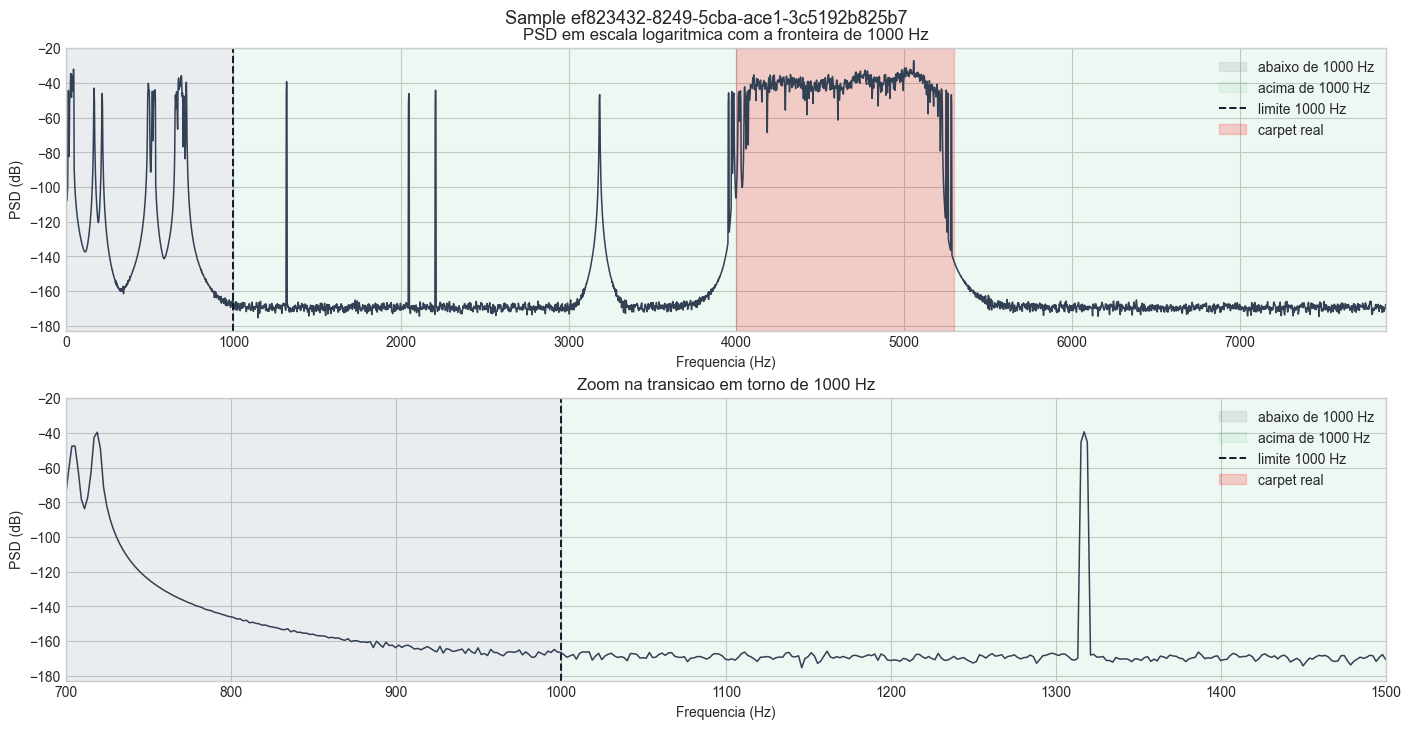

In [16]:
def plot_faixa_1000hz(sample_id):
    t, x, _, fs = load_wave(sample_id)
    freq, psd = compute_psd(t, x)
    log_psd = 10 * np.log10(psd + 1e-18) # coloque apenas psd se quiser ver sem a escala logaritmica do PSD
    freq_max_plot = min(8000, float(freq.max()))

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), constrained_layout=True)

    configs = [
        (axes[0], (0, freq_max_plot), 'PSD em escala logaritmica com a fronteira de 1000 Hz'),
        (axes[1], (700, min(1500, float(freq.max()))), 'Zoom na transicao em torno de 1000 Hz'),
    ]

    for ax, xlim, title in configs:
        ax.plot(freq, log_psd, color='#334155', lw=1.1)
        ax.axvspan(0, 1000, color='#64748b', alpha=0.13, label='abaixo de 1000 Hz')
        ax.axvspan(1000, freq.max(), color='#16a34a', alpha=0.07, label='acima de 1000 Hz')
        ax.axvline(1000, color='#111827', ls='--', lw=1.4, label='limite 1000 Hz')

        for start_hz, end_hz in regions_for(sample_id):
            ax.axvspan(start_hz, end_hz, color='red', alpha=0.18, label='carpet real')

        ax.set_xlim(*xlim)
        ax.set_xlabel('Frequencia (Hz)')
        ax.set_ylabel('PSD (dB)')
        ax.set_title(title)
        unique_legend(ax)

    fig.suptitle(f'Sample {sample_id}', y=1.02, fontsize=13)
    plt.show()


plot_faixa_1000hz(positive_id)

Plot da inforção sem a escala logarítmica

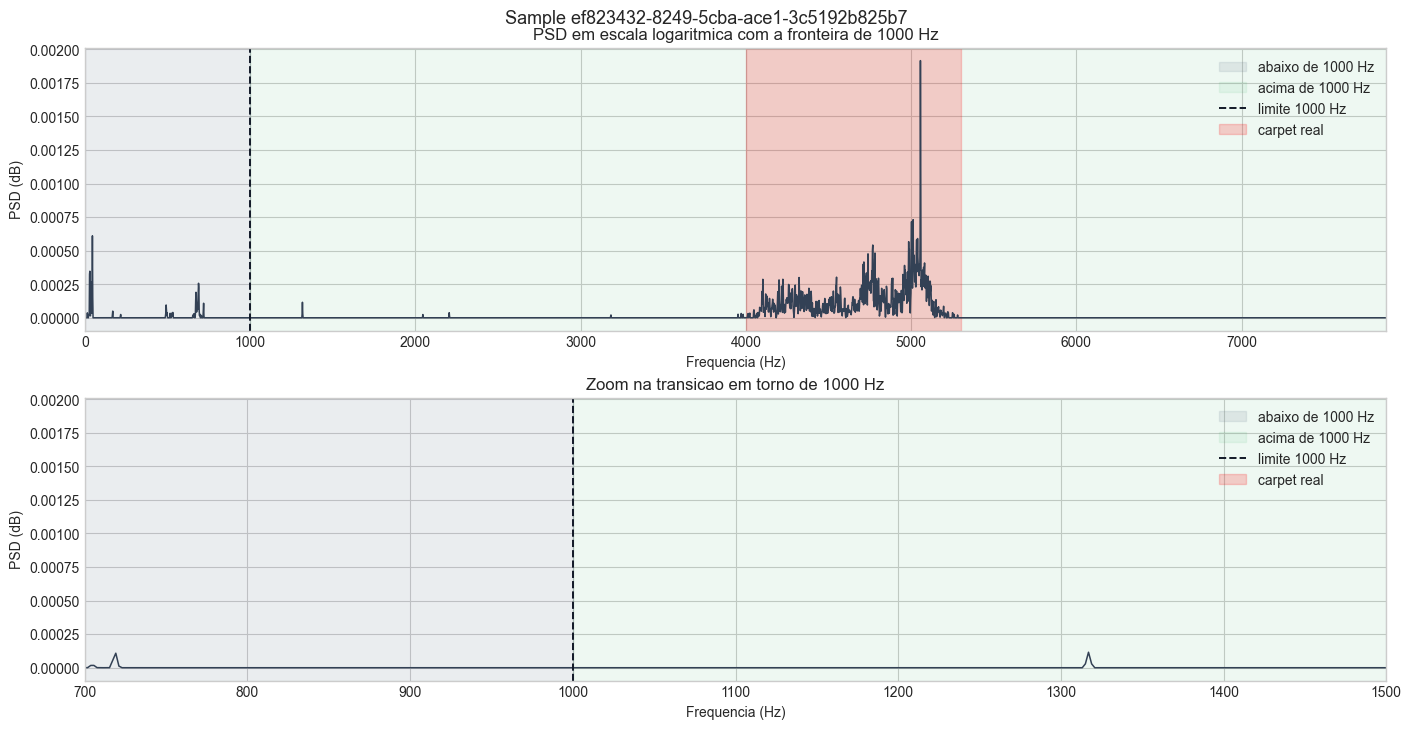

## Comparação entre o sinal no tempo com a FFT

O sinal no tempo ajuda a ver amplitude, duracao e comportamento bruto da vibração.
A FFT reorganiza o mesmo sinal por frequencia. Assim fica possivel enxergar se existe energia concentrada em linhas especificas ou uma elevacao mais espalhada do espectro.



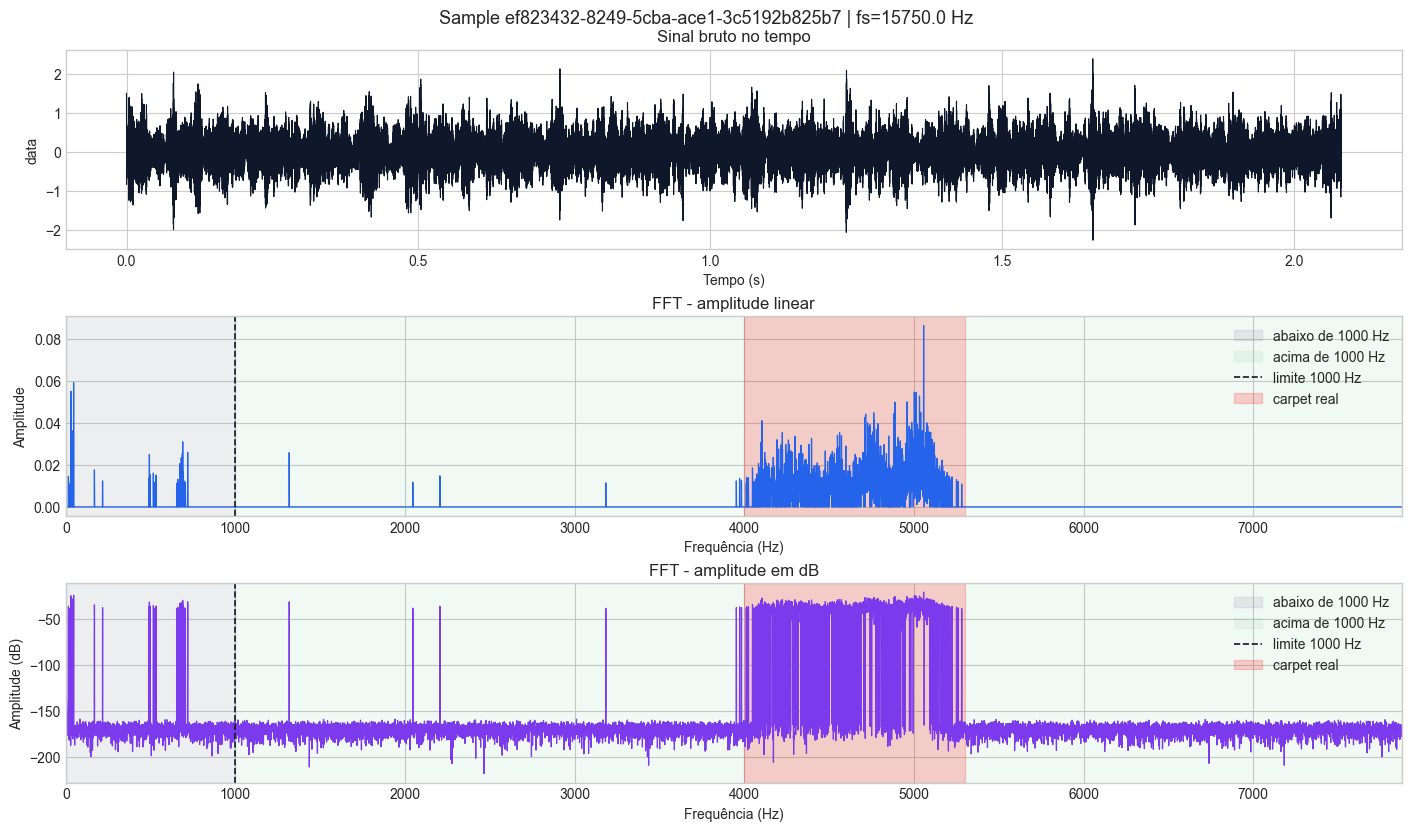

In [22]:
def plot_sinal_fft(sample_id, max_freq_hz=8000):
    t, x, _, fs = load_wave(sample_id)
    fft_freq, fft_amp, fft_amp_db = compute_fft(t, x)
    freq_max_plot = min(max_freq_hz, float(fft_freq.max()))

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), constrained_layout=True)

    axes[0].plot(t, x, color='#0f172a', lw=0.8)
    axes[0].set_title('Sinal bruto no tempo')
    axes[0].set_xlabel('Tempo (s)')
    axes[0].set_ylabel('data')

    axes[1].plot(fft_freq, fft_amp, color='#2563eb', lw=0.9)
    axes[1].set_title('FFT - amplitude linear')
    axes[1].set_xlabel('Frequência (Hz)')
    axes[1].set_ylabel('Amplitude')

    axes[2].plot(fft_freq, fft_amp_db, color='#7c3aed', lw=0.9)
    axes[2].set_title('FFT - amplitude em dB')
    axes[2].set_xlabel('Frequência (Hz)')
    axes[2].set_ylabel('Amplitude (dB)')

    for ax in axes[1:]:
        ax.axvspan(0, 1000, color='#64748b', alpha=0.12, label='abaixo de 1000 Hz')
        ax.axvspan(1000, fft_freq.max(), color='#16a34a', alpha=0.06, label='acima de 1000 Hz')
        ax.axvline(1000, color='#111827', ls='--', lw=1.2, label='limite 1000 Hz')

        for start_hz, end_hz in regions_for(sample_id):
            ax.axvspan(start_hz, end_hz, color='red', alpha=0.18, label='carpet real')

        ax.set_xlim(0, freq_max_plot)
        unique_legend(ax)

    fig.suptitle(f'Sample {sample_id} | fs={fs:.1f} Hz', y=1.02, fontsize=13)
    plt.show()


plot_sinal_fft(positive_id)

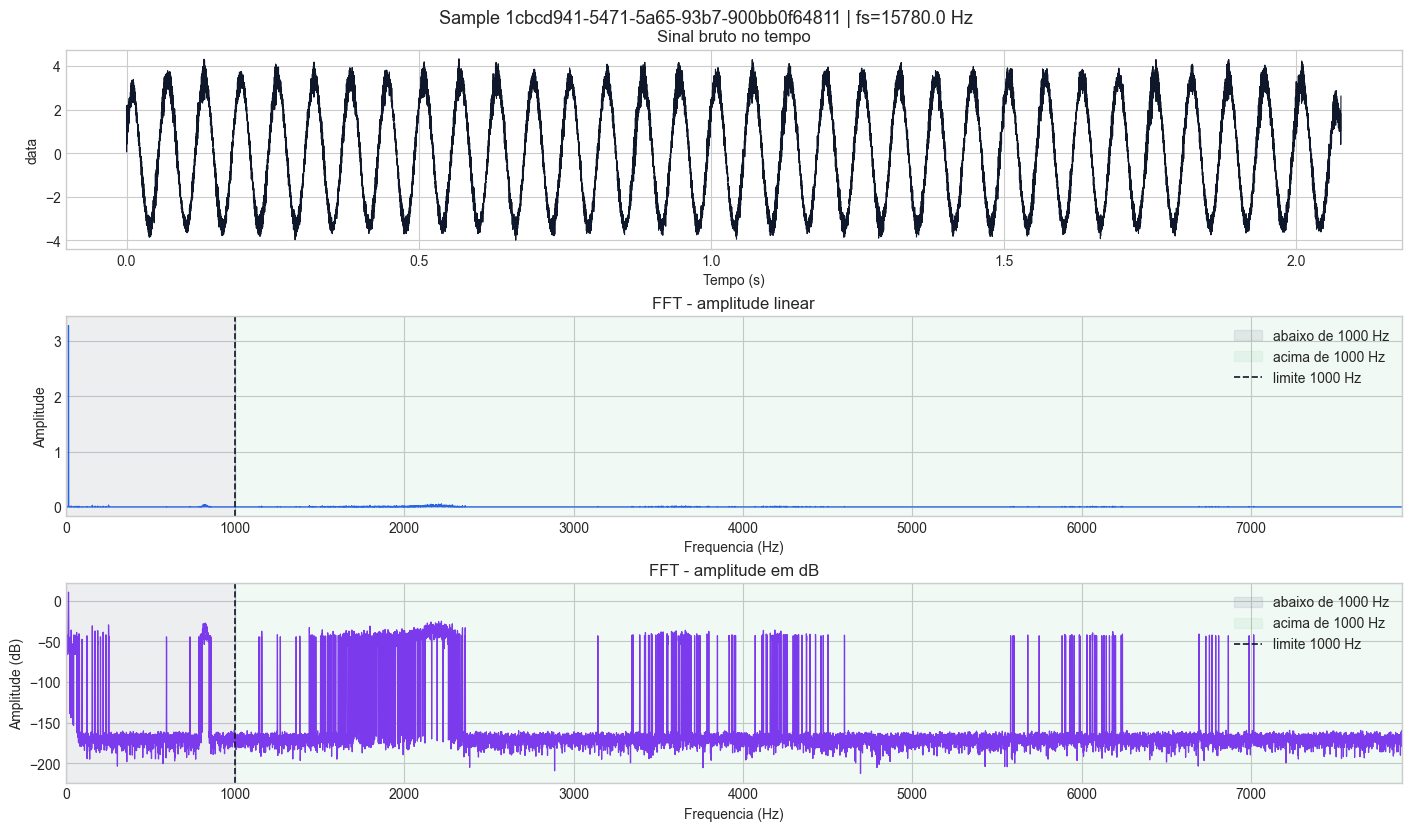

In [18]:
plot_sinal_fft(negative_id)

## Análise de informações suavizadas

FFT e PSD podem apresentar muitos ruídos, então uma suavização pode ajudar a identificar tendencias e padrões nas regiões que apresentão carpet. Se tornando uma análise preliminar da informação obtida

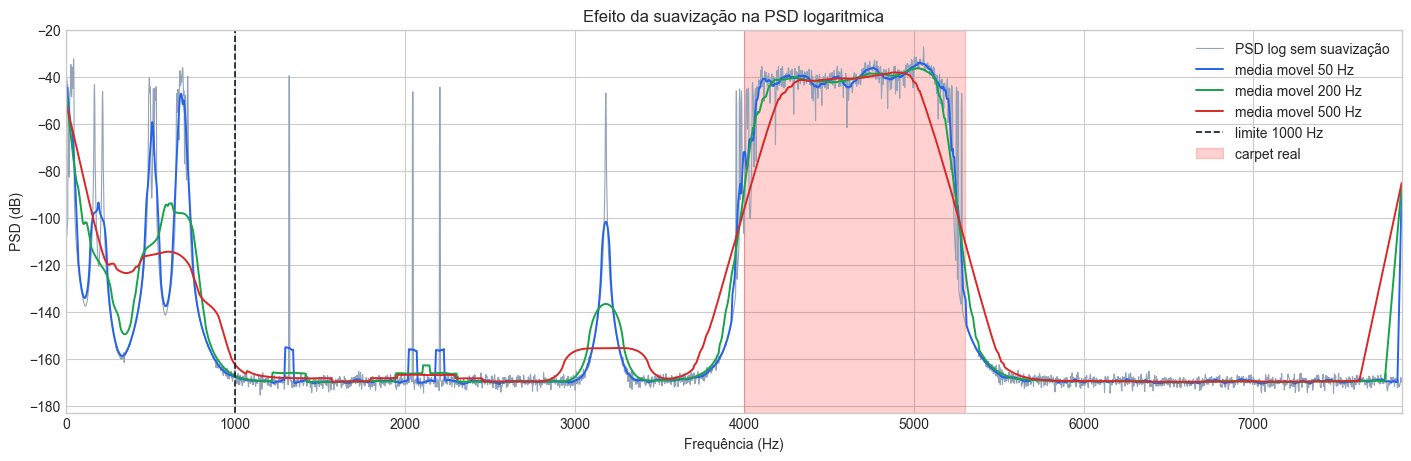

In [21]:
# identificação de um caso positivo para carpet

sample_id = positive_id
t, x, _, fs = load_wave(sample_id)
freq, psd = compute_psd(t, x)
log_psd = 10 * np.log10(psd + 1e-18) # conversão para escala logaritmica do PSD

fig, ax = plt.subplots(figsize=(14, 4.5), constrained_layout=True)
ax.plot(freq, log_psd, color='#94a3b8', lw=0.8, label='PSD log sem suavização')

for width_hz, color in [(50, '#2563eb'), (200, '#16a34a'), (500, '#dc2626')]: # plots das médias móveis com diferentes Hz
    ax.plot(
        freq,
        moving_average_by_hz(freq, log_psd, width_hz=width_hz),
        lw=1.4,
        color=color,
        label=f'media movel {width_hz} Hz',
    )

ax.axvline(1000, color='#111827', ls='--', lw=1.2, label='limite 1000 Hz')
for start_hz, end_hz in regions_for(sample_id):
    ax.axvspan(start_hz, end_hz, color='red', alpha=0.18, label='carpet real')

ax.set_xlim(0, min(8000, freq.max()))
ax.set_title('Efeito da suavização na PSD logaritmica')
ax.set_xlabel('Frequência (Hz)')
ax.set_ylabel('PSD (dB)')
unique_legend(ax)
plt.show()